# FINAL PROJECT — Volis Case Study

Name of the student: Rodrigo Santos

Dataset: volis_dataset.csv

Submission: this notebook (.ipynb) duly completed and reproducible

## 0) Imports and configurations

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer # Added SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Metrics
from sklearn.metrics import silhouette_score, adjusted_rand_score

# For reproducible results
RANDOM_STATE = 42

## 1) Data loading

In [90]:
DATA_PATH = "volis_dataset.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
0,Goucher College,True,1151.0,813.0,248.0,40.0,64.0,850.0,80.0,15588.0,6174.0,500.0,1200.0,78.0,90.0,9.2,34.0,16623.0,77.0
1,SUNY at Albany,False,13528.0,9198.0,1843.0,16.0,61.0,10168.0,1231.0,6550.0,4355.0,700.0,1560.0,93.0,96.0,17.4,16.0,9075.0,74.0
2,Lawrence University,True,1243.0,947.0,324.0,50.0,77.0,1129.0,74.0,17163.0,3891.0,525.0,975.0,76.0,92.0,10.1,57.0,13965.0,77.0
3,East Carolina University,False,9274.0,6362.0,2435.0,14.0,44.0,13171.0,1687.0,7248.0,3240.0,500.0,1700.0,74.0,78.0,13.2,18.0,9002.0,58.0
4,Amherst College,True,4302.0,992.0,418.0,83.0,96.0,1593.0,5.0,19760.0,5300.0,660.0,1598.0,93.0,98.0,8.4,63.0,21424.0,100.0


## 2) Dataset overview

Dimension (rows, columns): (977, 19)


,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
199,Ouachita Baptist University,True,910.0,773.0,450.0,31.0,73.0,1310.0,61.0,6530.0,2800.0,500.0,1500.0,63.0,67.0,13.3,10.0,6413.0,65.0
542,Northwest Missouri State University,False,2729.0,2535.0,1257.0,8.0,29.0,4787.0,472.0,3735.0,3136.0,250.0,1630.0,62.0,65.0,21.7,23.0,5284.0,54.0
174,Cabrini College,True,599.0,494.0,224.0,8.0,28.0,1035.0,446.0,10518.0,6250.0,300.0,300.0,59.0,76.0,16.5,36.0,7117.0,71.0
764,Joan of Arc College,NaN,100000.0,1500.0,500.0,20.0,40.0,50000.0,1.0,10000.0,5000.0,600.0,1500.0,60.0,60.0,15.0,100.0,NaN,60.0
66,Emily Dickinson College,False,2000.0,1500.0,500.0,20.0,40.0,2000.0,NaN,1000000.0,5000.0,600.0,1500.0,60.0,0.0,15.0,20.0,8000.0,60.0



Data types:
nm_college                          object
bl_private                          object
qt_applications_received           float64
qt_applications_accepted           float64
qt_students_enrolled               float64
qt_top_10_percent                  float64
qt_top_25_percent                  float64
qt_undergraduate_students          float64
qt_postgraduate_students           float64
vl_tuition_outstate                float64
vl_room_board                      float64
vl_books_cost                      float64
vl_personal_expenses               float64
pc_faculty_with_phd                float64
pc_faculty_with_terminal_degree    float64
vl_student_faculty_ratio           float64
pc_alumni_donors                   float64
vl_expenditure_per_student         float64
pc_graduation_rate                 float64
dtype: object

Statistical summary (numerical):


,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
count,962.000000,955.000000,956.000000,956.000000,962.000000,961.000000,960.000000,959.000000,957.000000,958.00000,965.000000,956.000000,955.000000,960.000000,961.000000,955.000000,963.000000
mean,3407.768191,2049.859686,792.927824,26.457113,52.904366,3518.034339,810.072917,12379.983316,4504.491118,604.24739,1443.190674,70.331590,75.779058,14.305208,22.551509,12425.086911,64.241952
std,8420.796455,2706.765606,1158.893541,17.123183,19.420941,5124.628362,1754.771752,45322.758310,1813.501606,698.62322,1714.550823,15.950903,16.837190,4.592944,12.597689,55674.935543,16.579696
min,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.100000,0.000000,1.000000,0.000000
25%,880.500000,702.000000,278.000000,17.000000,40.000000,1100.000000,131.750000,7860.000000,3700.000000,500.00000,920.000000,60.000000,60.000000,12.100000,15.000000,7086.500000,56.000000
50%,2000.000000,1500.000000,500.000000,20.000000,49.000000,2000.000000,300.000000,10000.000000,4514.000000,570.00000,1400.000000,71.000000,77.000000,14.700000,20.000000,8000.000000,60.000000
75%,2967.750000,2037.000000,724.000000,32.000000,65.000000,3051.000000,765.250000,12035.000000,5000.000000,600.00000,1525.000000,83.000000,90.000000,15.625000,29.000000,10077.000000,75.000000
max,100000.000000,26330.000000,10000.000000,100.000000,100.000000,50000.000000,21836.000000,1000000.000000,50000.000000,10000.00000,30000.000000,103.000000,100.000000,100.000000,100.000000,1000000.000000,118.000000



Boxplot for all variables


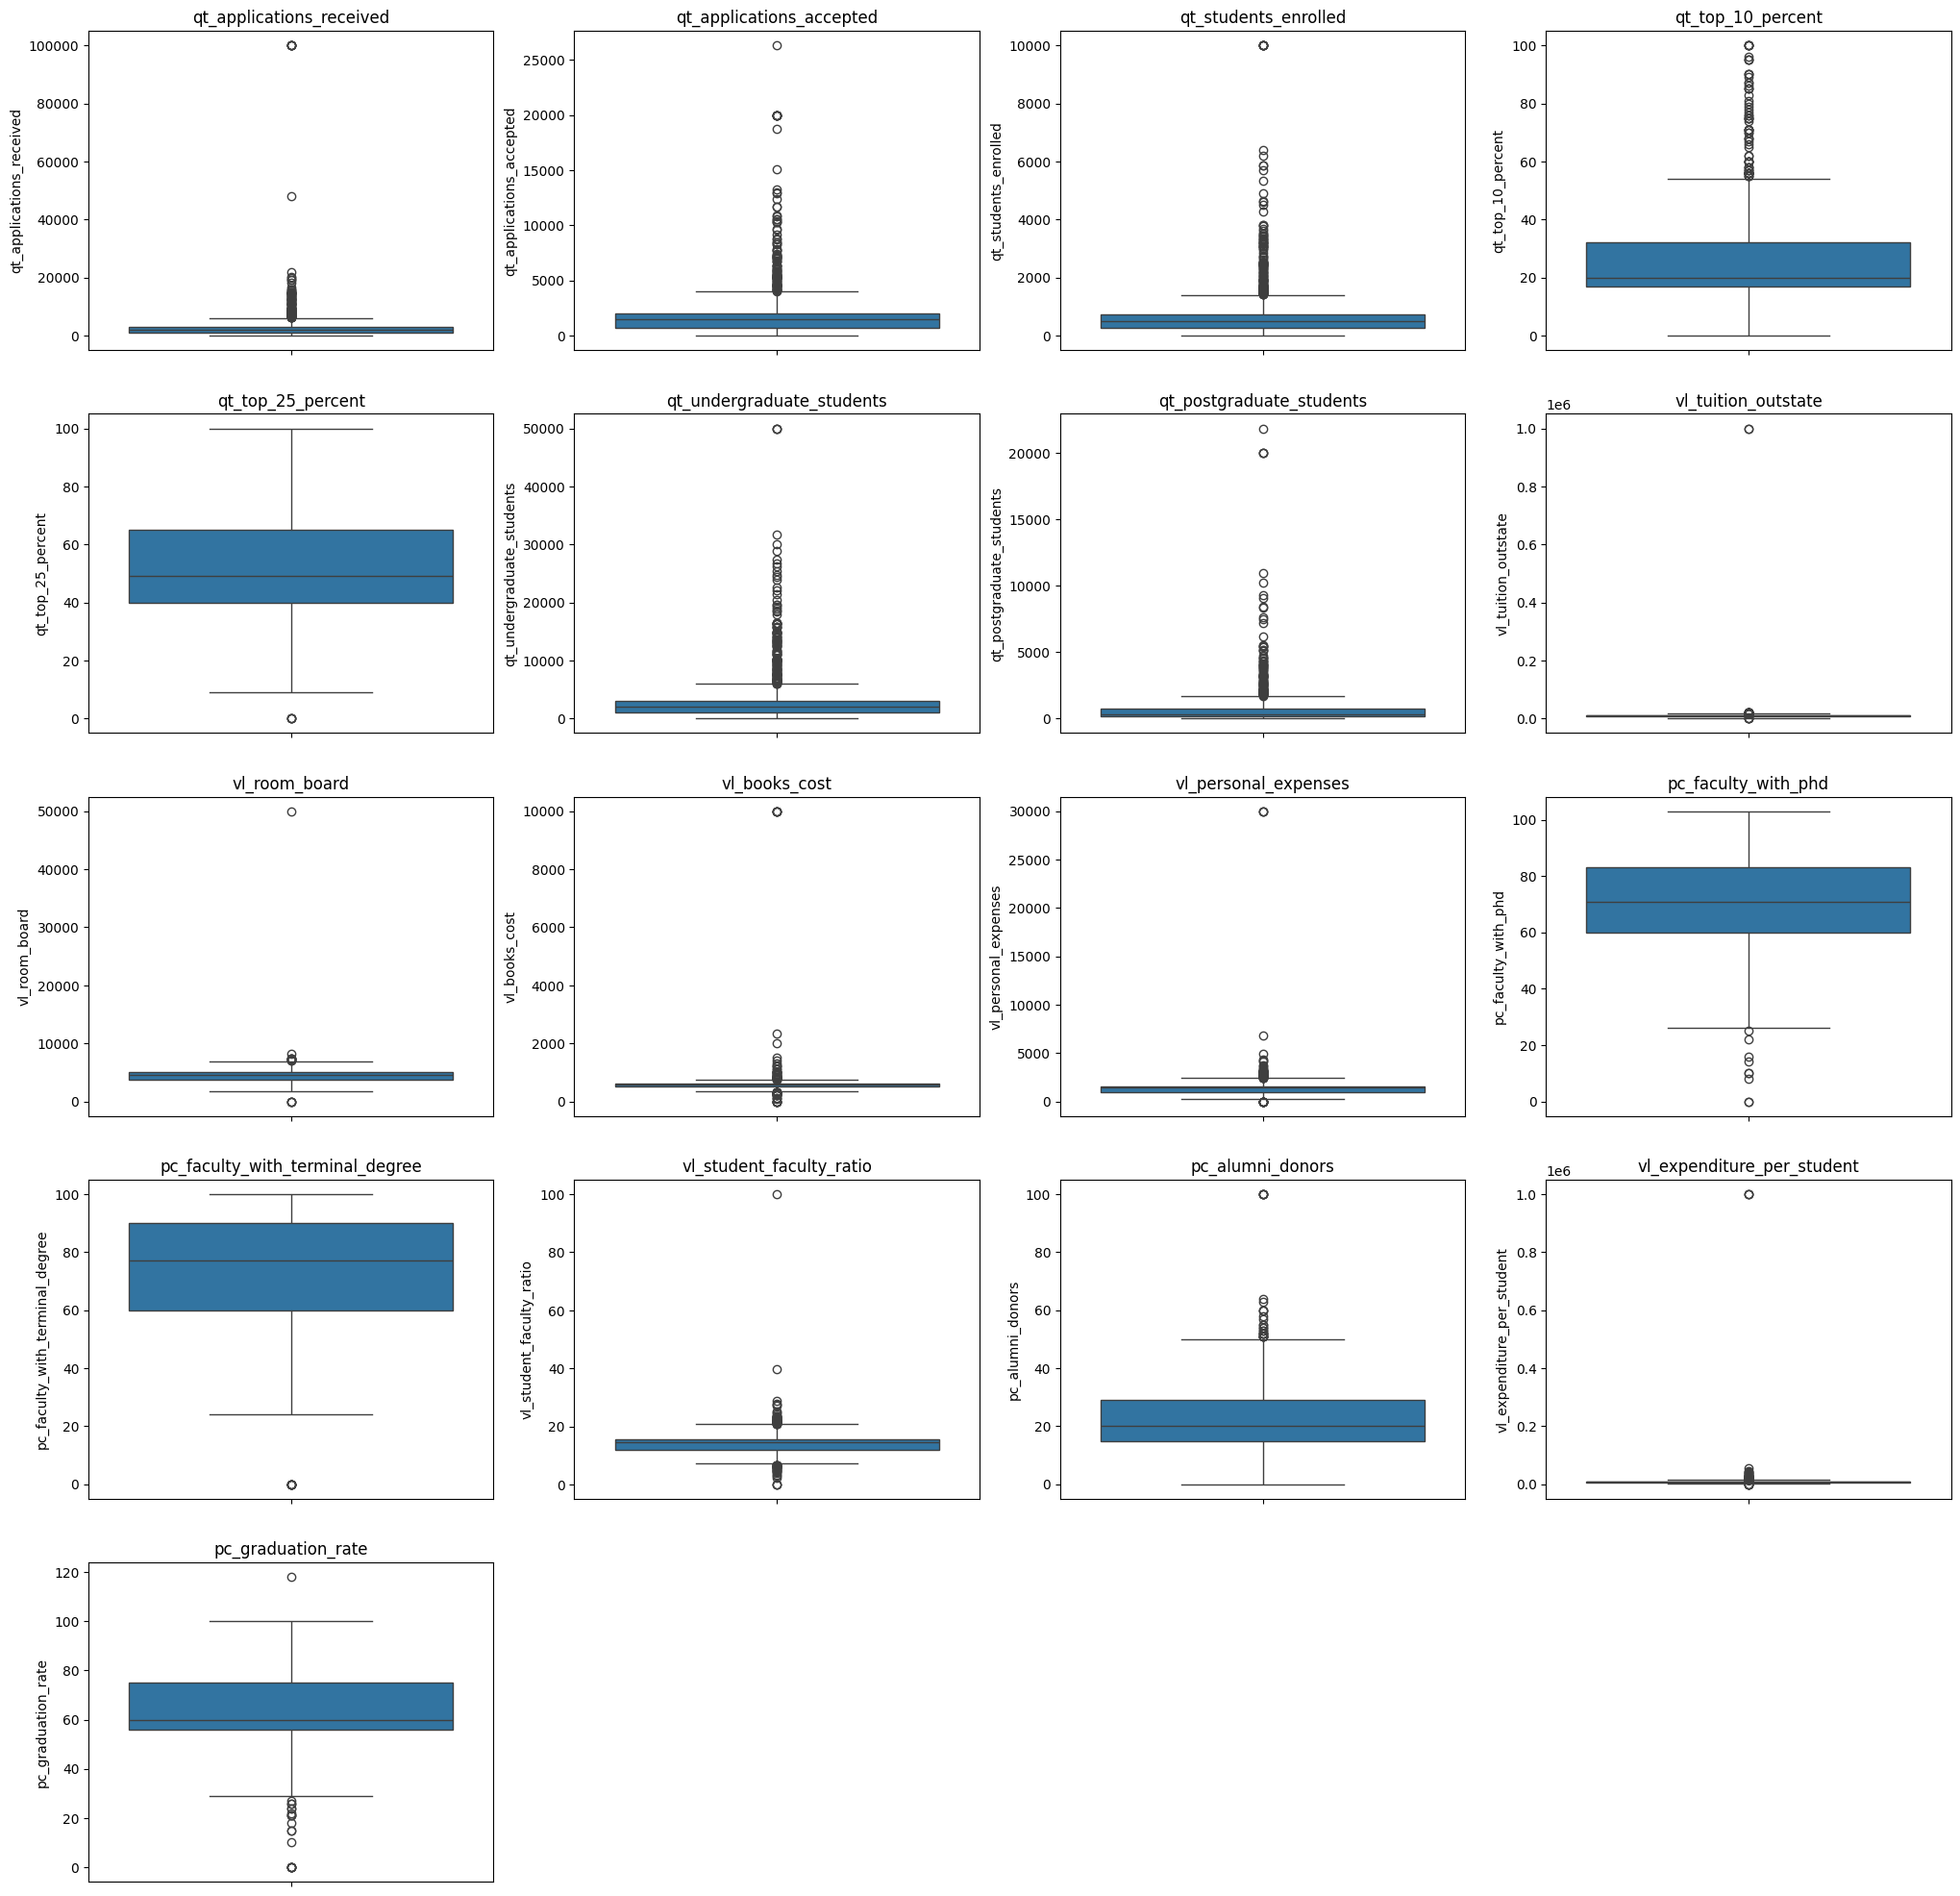

In [73]:
print("Dimension (rows, columns):", df.shape)
display(df.sample(5, random_state = RANDOM_STATE))
n_lines = df.shape[0]
n_cols = df.shape[1]
print("\nData types:")
print(df.dtypes)

print("\nStatistical summary (numerical):")
display(df.describe())

# Organize the dataset into variable X (only numerical values) and y (numerical target)
X = df.copy()
X = X.drop(columns = ['nm_college'])
X = X.drop(columns = ['bl_private'])
y = pd.DataFrame(df["bl_private"], columns = ["bl_private"])
col_names = X.columns.tolist() # List with numerical variable names

print("\nBoxplot for all variables")
plt.figure(figsize = (25,25))
for i in range(len(col_names)): # Boxplot for all numerical variables
    plt.subplot(5,4,i+1)
    sns.boxplot(X[col_names[i]])
    plt.title(col_names[i])
plt.show()

In this first approach, we got an overview of the dataset.

*   We were able to understand how many rows (instances) and how many variables (numerical and categorical) there are.

*   The dataset was also organized into two variables **X** (numerical variables) and **y** (targets), which will be useful later in the program.

*   A statistical summary and boxplots were also generated for each numerical variable: it is observed that there are variables that present outliers, different range scales between variables, something that will have to be treated later in data preparation.

## 3) Data quality: missing values and duplicates

In [74]:
#Nulls per column

null = df.isnull().sum() #Count of nulls per column
null_p = round(null/n_lines * 100,1) #Relative percentage of nulls

null_values = pd.DataFrame({"Number of nulls per column": null,
                            "Percentage (%)": null_p})
display(null_values) #Dataframe to visualize

#Duplicates
print("\nIs there any duplicated entry? ", df.duplicated().any())

#Imputation
imputer = SimpleImputer(strategy = 'median') #imputamos na variável X
X = pd.DataFrame(imputer.fit_transform(X), columns = col_names)

,Number of nulls per column,Percentage (%)
nm_college,0,0.0
bl_private,21,2.1
qt_applications_received,15,1.5
qt_applications_accepted,22,2.3
qt_students_enrolled,21,2.1
qt_top_10_percent,21,2.1
qt_top_25_percent,15,1.5
qt_undergraduate_students,16,1.6
qt_postgraduate_students,17,1.7
vl_tuition_outstate,18,1.8



Is there any duplicated entry?  False


In this section, we were able to understand how many values were missing per variable and imputed them using the median, as the existing *outliers* are significant.

I decided to impute the _data_ instead of removing it from the original _dataset_, since our _dataset_ is not very large ("only" 977 instances). Removing all instances with null values would result in an even smaller _dataset_, which would compromise the reliability of the results.

## 4) EDA: distributions and outliers (minimum: 3 to 6 useful graphs)

In [75]:
#In this section, we will deal with outliers and visualize the data
#after treatment

def outlier_summary(X): #We create a function to avoid repeating the code
                        #in the next section

  #We initialize three dictionaries that will store information on the number of outliers,
  #percentage and skewness for each column (dictionary keys)
  upper_counts = {} #upper outliers
  lower_counts = {} #lower outliers
  outlier_percentages = {} #percentage of outliers per variable
  skewness_values = {} #skewness value per variable

  #We use the "for" loop to evaluate each column:
  for col in col_names:
    #We calculate Q1, Q3 and IQR (interquartile range)
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    #We calculate the outlier limits for each quartile
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    #We identify the outliers and store them in the dictionaries
    upper_counts[col] = len(X[(X[col] > upper_bound)])
    lower_counts[col] = len(X[(X[col] < lower_bound)])
    outlier_percentages[col] = round((upper_counts[col]+lower_counts[col])/X.shape[0] * 100, 1)
    skewness_values[col] = round(X[col].skew(), 2)

  #We create a dataframe to better visualize the results of the "for" loop
  summary_X = pd.DataFrame({
      "Upper Outliers": pd.Series(upper_counts),
      "Lower Outliers": pd.Series(lower_counts),
      "Total Outliers:": pd.Series(upper_counts) + pd.Series(lower_counts),
      "Outlier Percentages (%)": pd.Series(outlier_percentages),
      "Skewness": pd.Series(skewness_values)
  })
  return summary_X

summary_X = outlier_summary(X)

#We visualize the dataframe in descending order of Skewness.
display(summary_X.sort_values(by = "Skewness", ascending = False))

,Upper Outliers,Lower Outliers,Total Outliers:,Outlier Percentages (%),Skewness
vl_tuition_outstate,51,4,55,5.6,21.85
vl_expenditure_per_student,93,5,98,10.0,17.79
vl_room_board,11,4,15,1.5,16.67
vl_personal_expenses,55,11,66,6.8,14.56
vl_books_cost,47,32,79,8.1,12.89
qt_applications_received,116,0,116,11.9,9.79
qt_postgraduate_students,107,0,107,11.0,7.21
vl_student_faculty_ratio,44,27,71,7.3,7.01
qt_students_enrolled,138,0,138,14.1,4.84
qt_undergraduate_students,146,0,146,14.9,4.24


In this code section, our goal is to create an evaluation criterion for *outliers* and understand the distribution of values within the variables. We observe that:

*   There are variables with a large number of *outliers*, representing up to 14.4% of the _data_ for that column
*   Most *outliers* occur above the upper limit
*   There are columns with a large right tail dictated by a skewness value much greater than 1

Considering these three observations, in the next code section we will treat these columns through a data transformation.

Thus, I chose to select columns that:

*   Have an *outlier* percentage above **5%** OR
*   Have a *skewness* value above **4**

In [76]:
no_transformation = ["pc_alumni_donors", "qt_top_25_percent", "pc_graduation_rate",
                     "pc_faculty_with_phd", "pc_faculty_with_terminal_degree"]

pt = PowerTransformer(method = "yeo-johnson")

for col in col_names:
  if col not in no_transformation:
    X[col] = pt.fit_transform(X[[col]])

summary_X = outlier_summary(X)
display(summary_X.sort_values(by = "Skewness", ascending = False))

,Upper Outliers,Lower Outliers,Total Outliers:,Outlier Percentages (%),Skewness
vl_room_board,6,7,13,1.3,2.23
vl_tuition_outstate,3,19,22,2.3,1.92
vl_books_cost,43,48,91,9.3,1.77
pc_alumni_donors,27,0,27,2.8,1.71
vl_expenditure_per_student,60,18,78,8.0,1.61
vl_personal_expenses,29,17,46,4.7,1.23
vl_student_faculty_ratio,35,37,72,7.4,0.60
qt_top_25_percent,0,4,4,0.4,0.55
qt_applications_received,28,8,36,3.7,0.18
qt_students_enrolled,61,11,72,7.4,0.16


In this section, data transformation was performed using the Yeo-Johnson method, as it showed to reduce the overall percentage of outliers and produce *skewness* values within or close to the range [-1, 1].

Logarithmic transformation worked well for high *outliers*, but not for low *outliers*, producing left-skewed distributions.

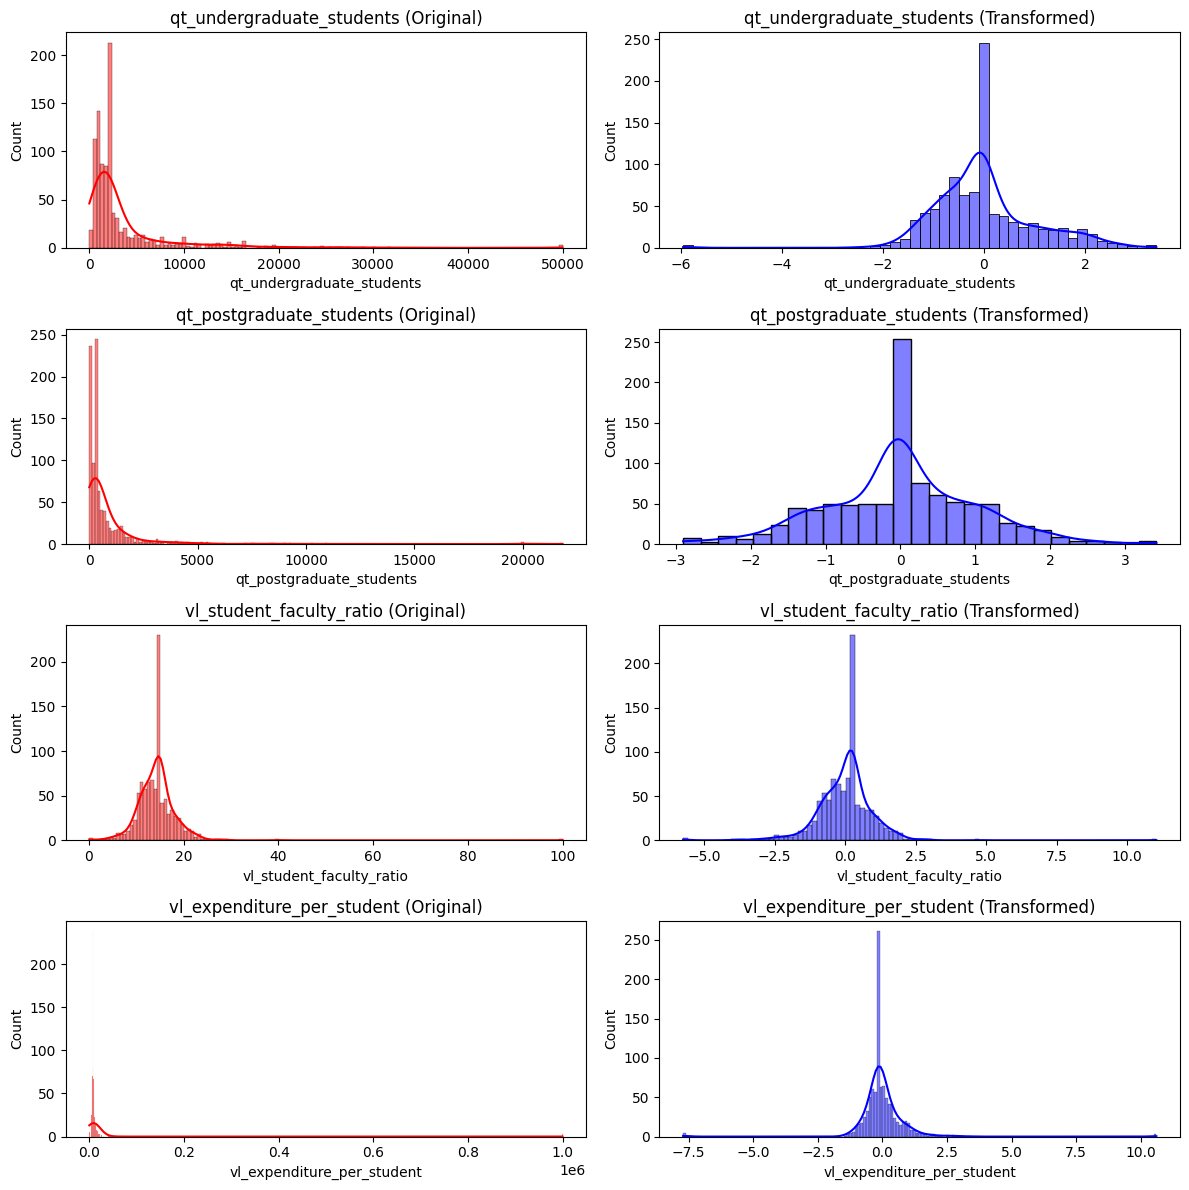

In [77]:
plt.figure(figsize = (12,12))

#Columns to show pre and post-transformation
example_plot = ["qt_undergraduate_students", "qt_postgraduate_students",
                "vl_student_faculty_ratio", "vl_expenditure_per_student"]

for i in range(len(example_plot)):
    # Plot of original data
    plt.subplot(len(example_plot), 2, 2*i + 1)
    sns.histplot(df[example_plot[i]], kde = True, color = "red")
    plt.title(f"{example_plot[i]} (Original)")

    # Plot of transformed data
    plt.subplot(len(example_plot), 2, 2*i + 2)
    sns.histplot(X[example_plot[i]], kde = True, color = "blue")
    plt.title(f"{example_plot[i]} (Transformed)")

plt.tight_layout()
plt.show()

Example of four variables before and after Yeo-Johnson transformation.

## 5) Directed question (mandatory):

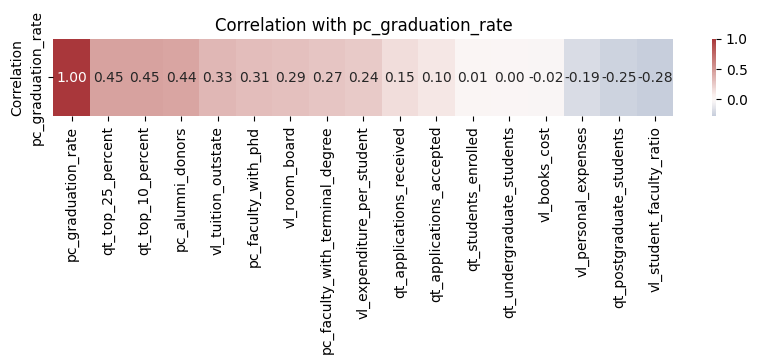

----------------------------------------------------------------------------------------------------
The 3 top correlations correspond to ['qt_top_25_percent', 'qt_top_10_percent', 'pc_alumni_donors']
----------------------------------------------------------------------------------------------------

Example of three scatter plots:


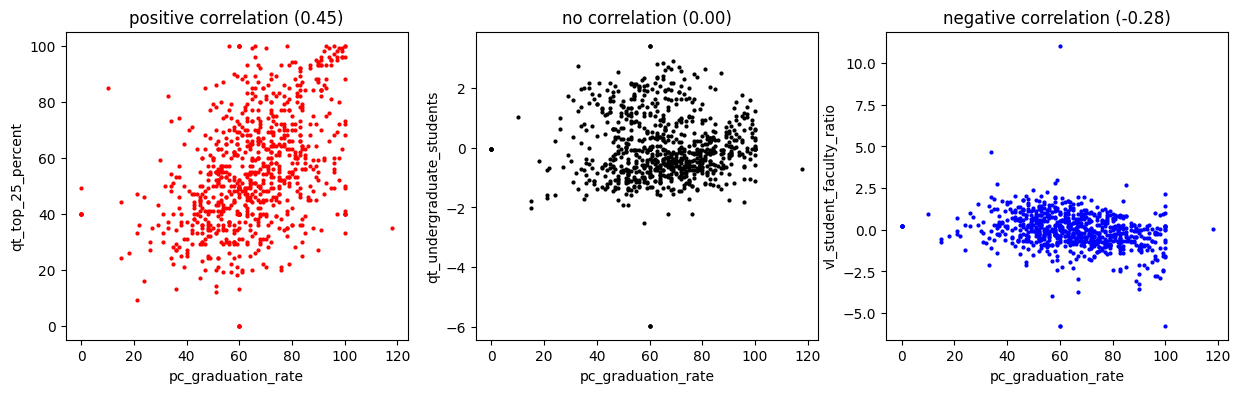

In [78]:
target_grad = "pc_graduation_rate"

#Correlation matrix for all variables in X
full_corr_matrix = X.corr()

#DataFrame for the correlation vector of target_grad in descending order
target_corr = pd.DataFrame(full_corr_matrix[target_grad]).sort_values(by = target_grad, ascending = False)

# Heatmap for the correlation vector
#The closer to zero, the heatmap takes a white (neutral) color
#The further from zero, it can take a reddish color (positive correlation)
#or bluish color (negative correlation)

plt.figure(figsize = (10, 1))
sns.heatmap(target_corr.T, annot = True, cmap = "vlag", fmt = ".2f", cbar = True, center = 0)
plt.title(f"Correlation with {target_grad}")
plt.ylabel("Correlation")
plt.show()

#Select the n features with the highest correlation to target_grad
n = 3
top_corr = np.abs(target_corr.drop("pc_graduation_rate")).head(n).index.tolist()
print("-" * 100)
print(f"The {n} top correlations correspond to {top_corr}")
print("-" * 100)

#Example of the three correlation cases
y_example = ["qt_top_25_percent", "qt_undergraduate_students", "vl_student_faculty_ratio"] #example columns
colors = ["red", "black", "blue"] #list of colors for the graphs
titles = ["positive correlation (0.45)", "no correlation (0.00)", "negative correlation (-0.28)"]
print("\nExample of three scatter plots:")
plt.figure(figsize=(15,4))
for i in range(len(y_example)):
    plt.subplot(1,3,i+1)
    plt.scatter(X["pc_graduation_rate"], X[y_example[i]], s = 4, c = colors[i])
    plt.xlabel(target_grad)
    plt.ylabel(y_example[i])
    plt.title(titles[i])

* The variables that seem most relevant are those with an absolute correlation coefficient greater than 0.40: *"qt_top_25_percent"*, *"pc_alumni_donors"* and *"qt_top_10_percent"*.

* The correlation of these 3 variables is expected, since the graduation rate correlates positively with a higher percentage of students who already had academic success in their previous school, and with a greater investment from alumni.

* However, there may be some spurious correlation in some variables. In the case of *"vl_tuition_outstate"* and *"vl_room_board"*, which appear in 4th and 6th places in the top correlations, respectively, it is not necessarily true that the higher the tuition fees of an institution or the cost of accommodation and food, the higher the graduation rate. Therefore, the data must be observed carefully.

## 6) Question created by the student (mandatory)

Does the percentage of alumni donors vary between public or private institutions?

<Figure size 400x300 with 0 Axes>

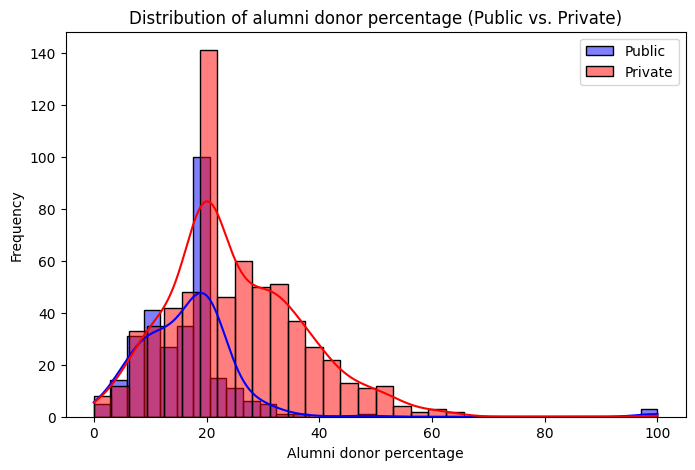


Median of 'pc_alumni_donors' for Public institutions: 17.00
Median of 'pc_alumni_donors' for Private institutions: 23.00


In [79]:
plt.figure(figsize = (4, 3))

#Logical vectors for institution types (public vs. private)
public_institutions = y["bl_private"] == False
private_institutions = y["bl_private"] == True

#Data selection for each institution type
alumni_public_data = X.loc[public_institutions, "pc_alumni_donors"]
alumni_private_data = X.loc[private_institutions, "pc_alumni_donors"]

#Histogram plot for both variables
plt.figure(figsize = (8, 5))
sns.histplot(alumni_public_data, kde = True, color = "blue", label = "Public")
sns.histplot(alumni_private_data, kde = True, color = "red", label = "Private")
plt.title("Distribution of alumni donor percentage (Public vs. Private)")
plt.xlabel("Alumni donor percentage")
plt.ylabel("Frequency")
plt.legend()
plt.show()

#Comparison of medians
median_public = alumni_public_data.median()
median_private = alumni_private_data.median()
print(f"\nMedian of 'pc_alumni_donors' for Public institutions: {median_public:.2f}")
print(f"Median of 'pc_alumni_donors' for Private institutions: {median_private:.2f}")

Private institutions appear to have a significantly higher percentage of alumni donors compared to public institutions, as evidenced by the medians and the histogram distribution. The median for private institutions is considerably higher, and the distribution for private institutions is more shifted towards higher values to the right.

## 7) Choose 1 Machine Learning challenge

In [80]:
CHALLENGE = "C"  # "A" = Classification | "B" = Regression | "C" = Clustering

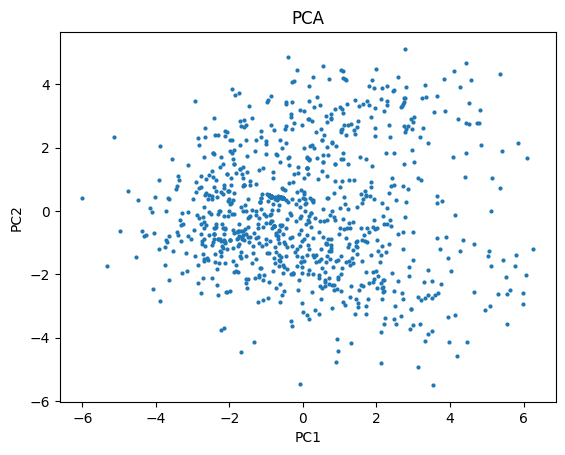

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# ============================================================
# 7C) CLUSTERING — institution segmentation
# ============================================================

# Impute missing values with the median before scaling
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Convert X_imputed back to a DataFrame to retain column names for clarity, though not strictly needed by StandardScaler
X_imputed_df = pd.DataFrame(X_imputed, columns=X.columns, index=X.index)

# 1st step - dataset standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed_df)

# 2nd step - PCA calculation for 95% variance preservation and visualization
pca = PCA(n_components = 0.95)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:, 0], X_pca[:, 1], s = 4)
plt.title("PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In the next section, we will use the k-Means method for creating *clusters*. After visualizing the data with PCA, we noticed that the distributions are reasonably spherical, so k-Means can be a good method to start clustering.

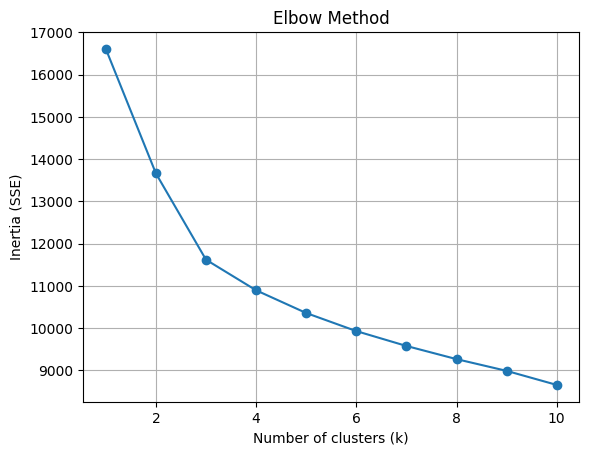

,Número de clusters,Silhouette score
0,1,NaN
1,2,0.20
2,3,0.21
3,4,0.17
4,5,0.15
5,6,0.15
6,7,0.16
7,8,0.14
8,9,0.13
9,10,0.14


In [82]:
#3rd step - let's calculate the best number of clusters
#using the elbow method and the silhouette score
sse = []
silhouette_scores = []
k_range = range(1, 11)

#calculation of the sum of squared errors (sse) and the silhouette score
#for k-numbers of clusters
for k in k_range:
    kmeans = KMeans(n_clusters = k, n_init = 10, random_state = 42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)
    labels = kmeans.fit_predict(X_scaled)
    if k > 1: # Silhouette score requires k>1
        silhouette_scores.append(round(silhouette_score(X_scaled, labels),2))
    else:
        silhouette_scores.append(np.nan)

#DataFrame for better representation of silhouette scores
silhouette = pd.DataFrame({
    "Número de clusters": k_range,
    "Silhouette score": silhouette_scores})

#Plot of the elbow method
plt.figure()
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.grid(True)
plt.show()
#Display of silhouette scores
display(silhouette)

* From k = 3, the decrease in error (SSE) is no longer very sharp.
* It is also confirmed that k = 3 has the highest silhouette score, demonstrating better data separation.
* Thus, we choose the value k = 3 for the number of *clusters*.

In [83]:
kmeans_final = KMeans(n_clusters = 3, n_init = 10, random_state = 42)
y_kmeans = kmeans_final.fit_predict(X_scaled)

To visualize the *clusters* formed through a two-dimensional representation, we will use PCA in the next section for its representation.

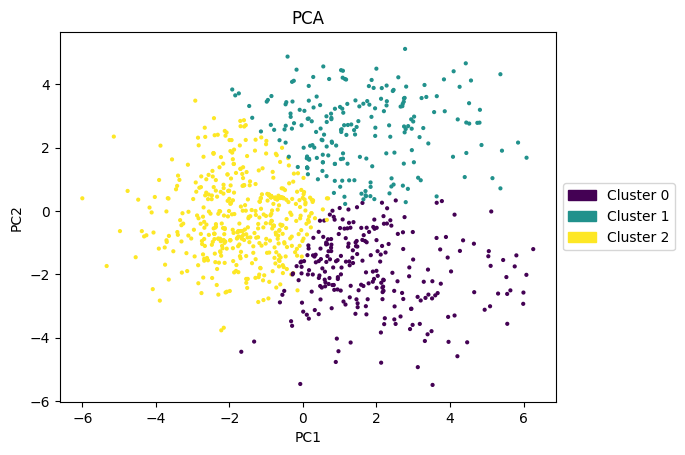

In [84]:
#Visualization of clusters
plt.scatter(X_pca[:, 0], X_pca[:, 1], s = 4, c = y_kmeans, cmap = "viridis")

#Assignment of each scatter plot color to a cluster in the legend
unique_clusters = np.unique(y_kmeans)
cmap = plt.get_cmap('viridis', len(unique_clusters))
legend_colors = [cmap(i) for i in unique_clusters]
handles = [
    mpatches.Patch(color=legend_colors[i], label=f'Cluster {unique_clusters[i]}')
    for i in range(len(unique_clusters))]

#Final Plot
plt.legend(handles = handles, loc = 'center left', bbox_to_anchor = (1, 0.5))
plt.title("PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

We can observe the three reasonably defined *clusters*.
In the next section, we will evaluate the profile of each cluster through its centroid.

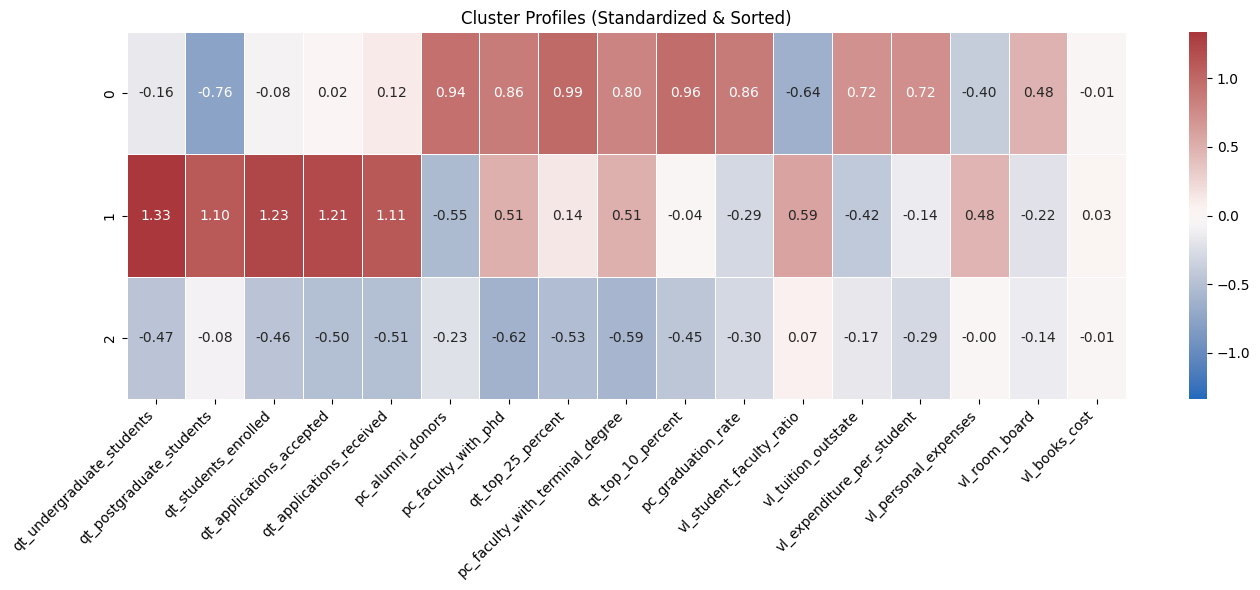

In [85]:
#Creation of a DataFrame for the centroids of each cluster
centers = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns = X.columns)

#Calculation of the maximum value (important for the heatmap scale)
vmax = np.abs(centers.values).max()

#Creates a new dataframe of centers, where the columns are sorted
#in descending order of standard deviation. This separation helps to visualize
#differences between clusters in the heatmap.
centers_sorted = centers[centers.std().sort_values(ascending=False).index]

plt.figure(figsize=(14,6))
sns.heatmap(centers_sorted, cmap = "vlag", center=0, #Center (neutral color)
            vmin=-vmax, #Symmetric of the maximum value
            vmax=vmax, linewidths=0.5, annot=True, fmt=".2f")

plt.title("Cluster Profiles (Standardized & Sorted)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

As expected, the 3 *clusters* have distinct profiles from each other.

*   **Cluster 0**: characterized by colleges that have a higher percentage of **top 10 and 25 students** from their original schools, **higher percentage of alumni donations, faculty with PhDs, faculty spending per student, and graduation rate, lower student/faculty ratio (allowing for better support)**. Students at these institutions also have **higher tuition, room, and board expenses**.

*   **Cluster 1**: characterized by a **high number of applications and enrolled students**. In contrast, the characteristics increased in cluster 0 **appear diminished here**. Possibly, this cluster will concentrate **public institutions**.

*   **Cluster 2**: characterized by a **general decrease in all characteristics**. Possibly, these will be **small institutions** (mostly private). It is the cluster with the most distinct profile of all, which is also confirmed through the PCA graphical representation.

It should also be noted that the book price variable remained constant across all three _clusters_, being therefore irrelevant for this clustering and could even be removed.

As expected, we observe **an increase in the graduation rate in institutions in the _cluster_ that receive more investment from _alumni_, invest more in their students, and where there is greater student support from faculty**. Thus, an important management action to maximize the graduation rate in other institutions would be to focus on investing in student support.

With the analysis of each *cluster*'s profile, the question arises: "how can the type of institution, public vs. private, influence its profile? Is there any trend within each *cluster*?"

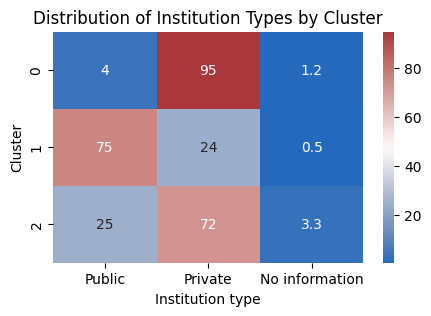

In [86]:
#What is the percentage of public and private institutions in each cluster?
cluster_data = y.copy()
cluster_data['cluster'] = kmeans_final.labels_ #adds the cluster_id to the initial dataframe

#Dictionary for each percentage value per cluster
public_percent = {}
private_percent = {}
no_value_percent = {}

#Stores the values in the dictionary
for i in range(3):
    cluster = cluster_data[cluster_data['cluster'] == i]
    public_percent[i] = round(cluster[cluster['bl_private'] == 0].shape[0]/cluster.shape[0]*100, 1)
    private_percent[i] = round(cluster[cluster['bl_private'] == 1].shape[0]/cluster.shape[0]*100, 1)
    no_value_percent[i] = round(int(cluster['bl_private'].isnull().sum())/cluster.shape[0]*100, 1)

# Creates a DataFrame from the created dictionaries
plot_df = pd.DataFrame({
    'Public': list(public_percent.values()),
    'Private': list(private_percent.values()),
    'No information': list(no_value_percent.values())})

#Visualization of percentages through a heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(plot_df, annot=True, cmap='vlag')
plt.title('Distribution of Institution Types by Cluster')
plt.xlabel('Institution type')
plt.ylabel('Cluster')
plt.show()

From the combined analysis of the *heatmap* above and the profile of each *cluster*, the following conclusions are drawn:
*   As expected, **cluster 0** is essentially formed by **private institutions**, which justifies its **more exclusive profile** (fewer students, students with high grades, and higher expenses per student).

*   **Cluster 1** shows a majority of **public institutions**, which was expected, as it has a larger number of applications and students.

*   **Cluster 2** presents a case of **smaller institutions**, where most are private.

**Should I have chosen another clustering method?**

As observed, the k-Means algorithm with k=3 produces a reasonable silhouette score (0.21), but close to the threshold for not indicated (<0.20). In addition, it is also observed that some values within each cluster are far from their centroid, which also influences its computation.

Thus, it is legitimate to ask whether the k-Means method is the most appropriate; and if using, for example, a hierarchical method would not be more appropriate for the separation of subtypes.

Now trying a hierarchical method...

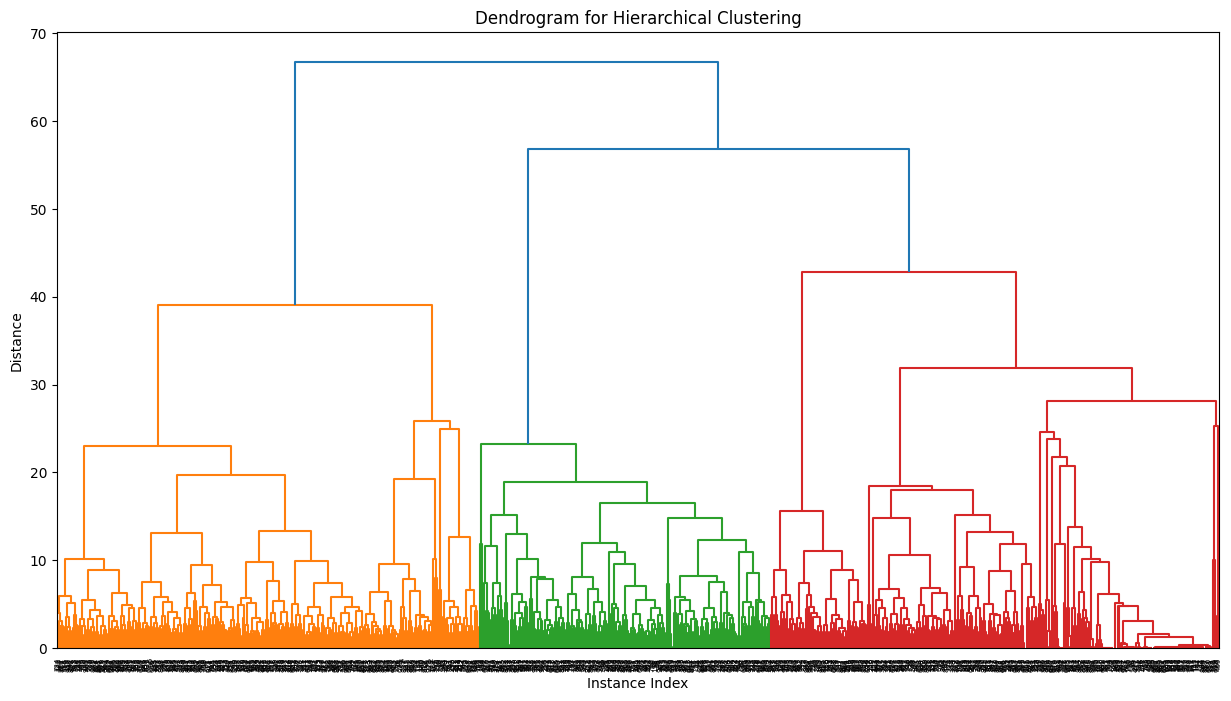

In [87]:
#Hierarchical clustering using the "ward" method (compact clusters)
linked_data = linkage(X_scaled, method="ward")

#Plot of the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linked_data)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Instance Index")
plt.ylabel("Distance")
plt.show()

The analysis of the dendrogram shows us that this hierarchical clustering algorithm produced:
*   Three *clusters* at a reasonable distance;
*   The 2nd and 3rd *clusters* are hierarchically closer.

In [88]:
#Comparing the number of instances of each cluster formed by k-Means and by
#hierarchical clustering
num_clusters_hierarchical = 3
hierarchical_labels = fcluster(linked_data, num_clusters_hierarchical, criterion = "maxclust")
crosstab_labels = pd.crosstab(pd.Series(y_kmeans, name = "KMeans Cluster"),
                              pd.Series(hierarchical_labels - 1, name = "Hierarchical Cluster"))
display(crosstab_labels)

#Adjusted Rand Index - evaluates the similarity between clustering algorithms
ARS = adjusted_rand_score(y_kmeans, hierarchical_labels - 1)
print(f"\nAdjusted Rand Score: {ARS:.2f}")

#Silhouette score again to compare the two methods
silhouette_kmeans = silhouette_score(X_scaled, y_kmeans)
silhouette_hierarchical = silhouette_score(X_scaled, hierarchical_labels - 1)

print(f"Silhouette Score (K-Means): {silhouette_kmeans:.2f}")
print(f"Silhouette Score (Hierarchical): {silhouette_hierarchical:.2f}")

Hierarchical Cluster,0,1,2
KMeans Cluster,,,
0,242,4,3
1,28,1,182
2,85,240,192



Adjusted Rand Score: 0.29
Silhouette Score (K-Means): 0.21
Silhouette Score (Hierarchical): 0.13


If we compare the total number of instances assigned to the *clusters* formed by k-Means and by hierarchical clustering, we verify that:
*   Both algorithms produce three *clusters* consistently;

*   **K-Means cluster 0** shares the majority of its instances with hierarchical algorithm cluster 0 (cluster overlap);

*   **K-Means cluster 1** aligns the majority of its instances with hierarchical cluster 2;

*   **K-Means cluster 2** aligns a larger percentage of its instances with hierarchical cluster 1, however there is some _leakage_ into clusters 0 and 2.

Comparing the two algorithms by the _adjusted rand index_ we obtain a value of 0.29, meaning that the two algorithms produce distinct results, mainly due to the _leakage_ that occurred in **K-Means cluster 2**.

On the other hand, the silhouette score of k-Means is **superior** to that of the hierarchical method.

Thus, it was decided to keep k-Means as the analysis algorithm.

## 8) Conclusions and final reflection (mandatory)

1) During the EDA, we saw that the scales between variables had different ranges, there were missing values, and also a significant amount of *outliers* (upper and lower) per variable.
To deal with the existence of *outliers* (critical for k-Means), **we proceeded with data transformation using the Yeo-Johnson method**. It was found that the application of the **logarithmic function** dealt well with upper *outliers*, decreasing the right tail, however, **lower _outliers_ were not altered**.
The **Yeo-Johnson method** was the one that simultaneously managed to **better deal with lower and upper _outliers_**, creating a _dataset_ with smaller percentages of *outliers* and *skewness* values closer to the range [-1, 1].

2) After preparing the data, we correlated the different variables with the variable *"pc_graduation_rate"* which evaluates the academic success of educational institutions. We observed that the **3** variables that most positively influence the academic success rate are: the **percentage of top 25 and top 10 students from their original schools and the percentage of _alumni_ donors**.
This is expected, as there is a tendency for students with good past results to continue achieving good results. On the other hand, *alumni* donations will be used to invest in teaching conditions, **enabling good learning and a better graduation rate**. As already mentioned above, it is necessary to pay attention to data analysis due to the existence of spurious correlation in some variables.

3) The chosen ML challenge, using unsupervised learning, allowed us to answer **whether there are different profiles of colleges, regardless of their type (public vs. private)**. The best approach, considering the _elbow plot_ and the _silhouette score_, revealed that the existence of three *clusters* would be the most reliable for the k-Means algorithm. These three *clusters* allowed identifying three distinct profiles:
* Cluster 0: Institutions with higher investment and graduation rate, where the best students are concentrated. **(~95% private)**

* Cluster 1: Larger institutions with less investment and lower graduation rate. **(~75% public)**

* Cluster 2: Small institutions with little investment. **(~72% private)**

  If the chosen challenge had used supervised learning, we would have missed these sub-populations and diversity within each public or private subtype.

  It is also concluded that investment in education is key to better academic performance.

4) The provided _dataset_ allows us to confirm, through data analysis, something that seems intuitive to us:
**Academic success depends on the college's investment capacity per student.**
  
  The data presented for institutions that **receive more donations**, have a **lower student-to-faculty ratio**, and **higher spending/investment per student** show significantly **better graduation results**.

  However, there is some missing data here for a complete analysis of this investment, as we do not have access to data on the **total budget** of educational institutions.

  It is necessary to understand in the **total budget** what percentage corresponds to **tuition fees** of each institution, what is the percentage contribution of **_alumni_ donations**, if there are sources of **external funding** or **public-private partnerships**.

  It is also necessary to understand what the **target of expenses** will be for the budgets: hiring professors and non-teaching staff, maintaining research departments (certain departments will have more expenses than others), management activities, among others.

  Only then will we be able to have information on the **budgetary profile** of each institution and propose **better management methods** to **maximize the graduation rate** without jeopardizing the proper functioning of other sectors of the college.